In [1]:
from astropy.io import fits
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP import DP
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
import pandas as pd
from astropy.coordinates import SkyCoord, search_around_sky
import astropy.units as u

In [2]:
# gz_df = pd.read_csv('/Users/hyp0515/data/gz_decals_auto_posteriors.csv')
gz_df = pd.read_csv('/Users/hyp0515/data/gz_desi_deep_learning_catalog_friendly.csv')
gz_df.head()

,dr8_id,ra,dec,brickid,objid,smooth-or-featured_smooth_fraction,smooth-or-featured_featured-or-disk_fraction,smooth-or-featured_artifact_fraction,disk-edge-on_yes_fraction,disk-edge-on_no_fraction,...,spiral-arm-count_3_fraction,spiral-arm-count_4_fraction,spiral-arm-count_more-than-4_fraction,spiral-arm-count_cant-tell_fraction,merging_none_fraction,merging_minor-disturbance_fraction,merging_major-disturbance_fraction,merging_merger_fraction,catalog_version,legacy_survey_data_release
0,100000_1081,32.084931,-44.311422,100000,1081,0.69,0.25,0.06,NaN,NaN,...,NaN,NaN,NaN,NaN,0.84,0.12,0.02,0.01,1.0.0,DR8
1,100000_1401,32.140085,-44.293668,100000,1401,0.77,0.12,0.11,NaN,NaN,...,NaN,NaN,NaN,NaN,0.60,0.15,0.05,0.21,1.0.0,DR8
2,100000_1483,32.275015,-44.288957,100000,1483,0.81,0.10,0.08,NaN,NaN,...,NaN,NaN,NaN,NaN,0.59,0.17,0.04,0.19,1.0.0,DR8
3,100000_1509,32.045648,-44.287172,100000,1509,0.64,0.27,0.09,NaN,NaN,...,NaN,NaN,NaN,NaN,0.17,0.07,0.05,0.71,1.0.0,DR8
4,100000_1869,32.170627,-44.267273,100000,1869,0.88,0.05,0.07,NaN,NaN,...,NaN,NaN,NaN,NaN,0.68,0.25,0.05,0.02,1.0.0,DR8


In [3]:
DP = DP()
all_df, _, _, _ = DP.extract_fits_data('./catalogs/all_catalog_test.fits')
all_df.head()

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,dv_r,dv_l,sigma_r,sigma_l,...,OII3726_rank,OII3729_rank,Hbeta_rank,OIII4959_rank,OIII5007_rank,NII6548_rank,Halpha_rank,NII6583_rank,SII6716_rank,SII6731_rank
0,39627739380056197,177.003815,-1.903397,0.224113,10.250154,-0.348563,55.811222,-14.713209,0.010000,60.631390,...,8,6,5,9,7,4,0,2,3,1
1,39627739380056420,177.013474,-1.972766,0.102005,9.722919,-0.349153,46.055069,-20.438494,0.010000,33.893749,...,6,4,3,8,7,5,0,2,1,9
2,39627739380056564,177.019318,-1.965308,0.323187,10.452706,0.941032,53.451893,-78.319199,50.218773,30.572901,...,4,2,5,8,3,6,0,1,7,9
3,39627739380056768,177.028137,-1.960056,0.102814,10.143390,0.193251,3.382933,-130.222778,43.977993,0.010000,...,7,4,5,9,6,8,0,2,1,3
4,39627739380056864,177.032974,-1.909970,0.167324,10.575974,-9.632146,9.486232,-173.880569,85.053467,59.080162,...,7,5,6,9,8,3,0,1,2,4


# Match common targets on both catalogs

In [4]:
coord_gz = SkyCoord(ra=gz_df['ra'].values*u.deg, dec=gz_df['dec'].values*u.deg)
coord_all = SkyCoord(ra=all_df['RA'].values*u.deg, dec=all_df['DEC'].values*u.deg)

ii_gz, ii_all, _, _ = search_around_sky(coord_gz, coord_all, seplimit=0.5*u.arcsec)

In [5]:
gz_common = gz_df.iloc[ii_gz].copy()
all_common = all_df.iloc[ii_all].copy()


In [6]:
print(len(gz_common))
print(len(all_common))

32681
32681


# Find close pairs on single catalog

In [7]:
from astropy.cosmology import Planck18 as cosmo

# Define search thresholds
initial_sep_threshold_arcsec = 75.0  # A generous initial search radius in arcseconds
z_sep_upper_threshold = 0.003 # delta_z
z_sep_lower_threshold = 0.0001 # delta_z

# Define a physical separation threshold in kpc
physical_sep_kpc = 50.0 # kpc


# Find all pairs within the initial, generous angular separation threshold
idx1, idx2, sep2d, _ = coord_all.search_around_sky(coord_all, initial_sep_threshold_arcsec*u.arcsec)

# Filter out self-matches
unique_pairs_mask = idx1 < idx2
idx1 = idx1[unique_pairs_mask]
idx2 = idx2[unique_pairs_mask]
sep2d = sep2d[unique_pairs_mask]

# Create a DataFrame of potential pairs
pair_candidates = pd.DataFrame({
    'idx1': idx1,
    'idx2': idx2,
    'separation_arcsec': sep2d.arcsec
})

# Get redshifts for the pairs
z1 = all_df['Z'].values[pair_candidates['idx1']]
z2 = all_df['Z'].values[pair_candidates['idx2']]
pair_candidates['z_diff'] = np.abs(z1 - z2)
pair_candidates['z_mean'] = (z1 + z2) / 2.0

pair_candidates = pair_candidates[pair_candidates['z_mean']>0.01].copy() # Exclude very low redshift pairs to avoid issues with angular diameter distance at z~0
# Filter by redshift difference first
close_z_pairs_df = pair_candidates[(pair_candidates['z_diff'] < z_sep_upper_threshold) & (pair_candidates['z_diff'] > z_sep_lower_threshold)].copy()

# Calculate the dynamic angular separation threshold for each pair based on its mean redshift
# This threshold corresponds to the defined physical separation
with np.errstate(divide='ignore'): # Ignore division by zero for z=0
    angular_sep_threshold_deg = (physical_sep_kpc / cosmo.kpc_proper_per_arcmin(close_z_pairs_df['z_mean']) / 60.0).value

# Convert the dynamic threshold to arcseconds
close_z_pairs_df['dynamic_sep_threshold_arcsec'] = angular_sep_threshold_deg * 3600

# Filter pairs based on the dynamic angular separation threshold
close_pairs_df = close_z_pairs_df[close_z_pairs_df['separation_arcsec'] < close_z_pairs_df['dynamic_sep_threshold_arcsec']].reset_index(drop=True)

# Calculate the physical separation in kpc
with np.errstate(divide='ignore'):
    kpc_per_arcmin = cosmo.kpc_proper_per_arcmin(close_pairs_df['z_mean']).value
close_pairs_df['physical_separation_kpc'] = (close_pairs_df['separation_arcsec'] / 60.0) * kpc_per_arcmin

# Add TARGETID to the final close pairs dataframe
close_pairs_df['TARGETID1'] = all_df['TARGETID'].values[close_pairs_df['idx1']]
close_pairs_df['TARGETID2'] = all_df['TARGETID'].values[close_pairs_df['idx2']]

close_pairs_df.drop(columns=['idx1', 'idx2'], inplace=True)


In [16]:

# Display the first few pairs found
print(f"Found {len(close_pairs_df)} close pairs.")
print("Catalog of close pairs:")
close_pairs_df.sort_values(by='physical_separation_kpc', ascending=False).head(20)

Found 717 close pairs.
Catalog of close pairs:


,separation_arcsec,z_diff,z_mean,dynamic_sep_threshold_arcsec,physical_separation_kpc,TARGETID1,TARGETID2
522,13.188511,0.000439,0.229295,13.208453,49.924511,39627800042279768,39627800042279813
321,27.863985,0.001474,0.093233,27.910261,49.917098,39627775673374684,39627775673374715
267,30.476173,0.000663,0.083933,30.668890,49.685813,39627764319393691,39627764319393887
42,12.030538,0.000140,0.257377,12.124697,49.611706,39627745591823845,39627745591823867
637,11.987392,0.000965,0.258555,12.084469,49.598339,39627812574860100,39627812574860126
37,13.578954,0.000275,0.218669,13.692807,49.584261,39627745524713179,39627745524713257
656,33.823208,0.000130,0.074637,34.115354,49.571823,39627818014871038,39627818014871126
464,30.948507,0.000255,0.082261,31.231030,49.547690,39627793838901559,39627793838901664
153,31.397715,0.000171,0.080908,31.703319,49.518022,39627757503647382,39627757503647561
459,20.453949,0.000170,0.131568,20.667169,49.484157,39627793775987181,39627793775987273


In [9]:
pair_target_ids = set(close_pairs_df['TARGETID1']) | set(close_pairs_df['TARGETID2'])
pair_df = all_df[all_df['TARGETID'].isin(pair_target_ids)].copy()

# Find isolated sources

In [10]:
# Identify indices of galaxies in all_df that are NOT in a close pair
non_pair_indices = all_df[~all_df['TARGETID'].isin(pair_target_ids)].index

# Create a coordinate object for the non-pair galaxies
coord_non_pair = coord_all[non_pair_indices]

# Search for neighbors around the non-pair galaxies within the entire catalog
# Use a large search radius to be sure to find all potential neighbors up to the isolation threshold
# A search radius of 5 arcmin should be sufficient for typical redshifts in the sample
search_radius_arcmin = 5.0 * u.arcmin
idx_non_pair, idx_all, _, _ = search_around_sky(coord_non_pair, coord_all, seplimit=search_radius_arcmin)

# Filter out self-matches
nonself_mask = all_df.index[non_pair_indices[idx_non_pair]] != all_df.index[idx_all]
idx_non_pair = idx_non_pair[nonself_mask]
idx_all = idx_all[nonself_mask]

# Create a DataFrame of neighbors
neighbors_df = pd.DataFrame({
    'idx': all_df.index[non_pair_indices[idx_non_pair]],
    'neighbor_idx': all_df.index[idx_all]
})

# Calculate mean redshift and physical separation for each potential neighbor pair
z_gal = all_df['Z'].values[neighbors_df['idx']]
z_neighbor = all_df['Z'].values[neighbors_df['neighbor_idx']]
z_mean_neighbor = (z_gal + z_neighbor) / 2.0

with np.errstate(divide='ignore'):
    kpc_per_arcmin = cosmo.kpc_proper_per_arcmin(z_mean_neighbor).value

# Get angular separation from the original coordinate search
# We need to re-run the search to get the separations, or match by index which is more complex.
# Re-running is clearer.
_, _, sep2d_neighbors, _ = search_around_sky(coord_non_pair, coord_all, seplimit=search_radius_arcmin)
sep2d_neighbors_arcsec = sep2d_neighbors[nonself_mask].arcsec

neighbors_df['physical_separation_kpc'] = (sep2d_neighbors_arcsec / 60.0) * kpc_per_arcmin

# For each non-pair galaxy, find the minimum physical separation to any other galaxy
min_sep_df = neighbors_df.groupby('idx')['physical_separation_kpc'].min().reset_index()
min_sep_df.rename(columns={'physical_separation_kpc': 'min_physical_separation_kpc'}, inplace=True)

# Define the isolation threshold
isolation_threshold_kpc = 500.0

# Find galaxies where the minimum separation is greater than the threshold
isolated_indices = min_sep_df[min_sep_df['min_physical_separation_kpc'] > isolation_threshold_kpc]['idx']

# Create the final DataFrame of isolated galaxies
isolated_df = all_df.loc[isolated_indices].copy()
isolated_df = isolated_df.merge(min_sep_df, left_index=True, right_on='idx').drop(columns='idx')



In [11]:

print(f"Found {len(isolated_df)} isolated galaxies.")
isolated_df.sort_values('min_physical_separation_kpc', ascending=True).head()

Found 6234 isolated galaxies.


,TARGETID,RA,DEC,Z,LOGM,LOGSFR,dv_r,dv_l,sigma_r,sigma_l,...,OII3729_rank,Hbeta_rank,OIII4959_rank,OIII5007_rank,NII6548_rank,Halpha_rank,NII6583_rank,SII6716_rank,SII6731_rank,min_physical_separation_kpc
18758,39627769667126796,182.311432,-0.852153,0.356982,10.999753,1.402372,175.519684,-92.757919,98.913849,116.528168,...,4,9,8,3,7,0,1,2,5,500.015047
37371,39627794178637960,203.256470,0.309910,0.266290,10.275274,0.999210,71.505951,-39.161572,40.243820,40.951813,...,3,1,9,7,8,0,2,4,6,500.025970
9563,39627752151715983,218.417374,-1.544477,0.160668,10.311471,1.012049,94.543045,-34.230865,33.013237,91.274940,...,4,3,9,8,7,0,1,2,5,500.029271
49680,39627812369334778,207.521301,0.977050,0.265499,10.773126,1.172531,157.113831,-5.673310,323.578339,115.658211,...,5,1,9,3,7,0,2,4,6,500.059684
36295,39627793956341227,190.060760,0.211458,0.191905,10.540550,0.605929,135.894211,-3.143300,36.272572,116.454094,...,3,5,9,6,8,0,2,4,1,500.077604


# Comparison between galaxies with and without nearby companions

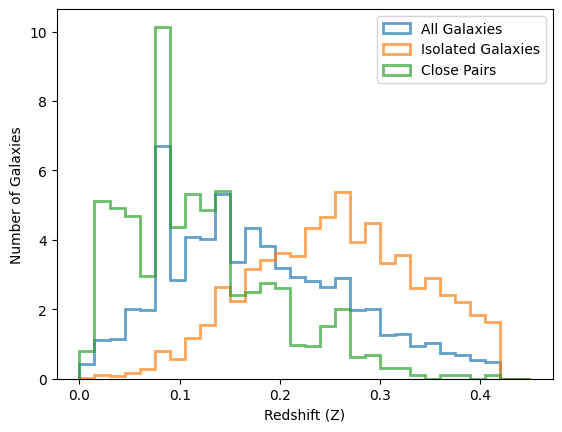

In [12]:
plt.hist(all_df['Z'], bins=30, alpha=0.7, label='All Galaxies', density=True, range=(0, 0.45), histtype='step', linewidth=2)
plt.hist(isolated_df['Z'], bins=30, alpha=0.7, label='Isolated Galaxies', density=True, range=(0, 0.45), histtype='step', linewidth=2)
plt.hist(pair_df['Z'], bins=30, alpha=0.7, label='Close Pairs', density=True, range=(0, 0.45), histtype='step', linewidth=2)
plt.xlabel('Redshift (Z)')
plt.ylabel('Number of Galaxies')
plt.legend()
plt.show()

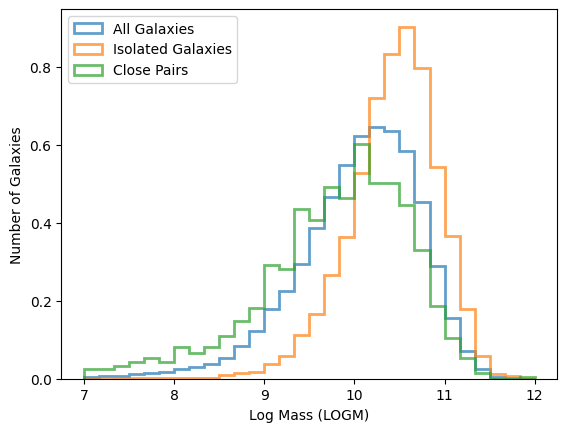

In [13]:
plt.hist(all_df['LOGM'], bins=30, alpha=0.7, label='All Galaxies', density=True, range=(7, 12), histtype='step', linewidth=2)
plt.hist(isolated_df['LOGM'], bins=30, alpha=0.7, label='Isolated Galaxies', density=True, range=(7, 12), histtype='step', linewidth=2)
plt.hist(pair_df['LOGM'], bins=30, alpha=0.7, label='Close Pairs', density=True, range=(7, 12), histtype='step', linewidth=2)
plt.xlabel('Log Mass (LOGM)')
plt.ylabel('Number of Galaxies')
plt.legend()
plt.show()

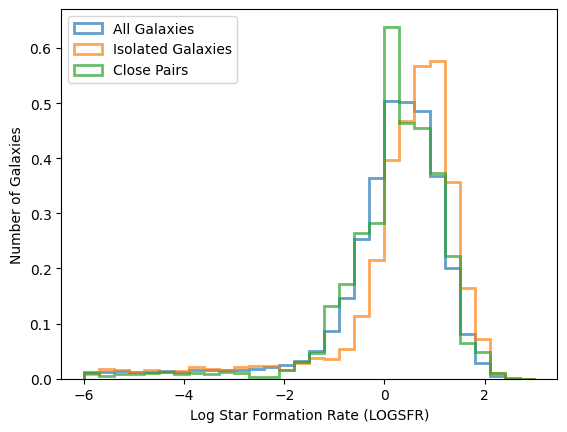

In [14]:
plt.hist(all_df['LOGSFR'], bins=30, alpha=0.7, label='All Galaxies', density=True, range=(-6, 3), histtype='step', linewidth=2)
plt.hist(isolated_df['LOGSFR'], bins=30, alpha=0.7, label='Isolated Galaxies', density=True, range=(-6, 3), histtype='step', linewidth=2)
plt.hist(pair_df['LOGSFR'], bins=30, alpha=0.7, label='Close Pairs', density=True, range=(-6, 3), histtype='step', linewidth=2)
plt.xlabel('Log Star Formation Rate (LOGSFR)')
plt.ylabel('Number of Galaxies')
plt.legend()
plt.show()